In [3]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
'''
# 1. טעינת הקובץ
file_path = 'drug_consumption.data'
# בודקים אם יש כותרות או לא - בקובץ המקורי אין.
# אם כבר שמרת עם כותרות, נקרא רגיל. אם לא, header=None.
try:
    df = pd.read_csv(file_path)
    if 'Age' not in df.columns: # אם זה לא קרא כותרות נכון
        df = pd.read_csv(file_path, header=None)
except:
    print("לא ניתן לקרוא את הקובץ. וודאי שהוא קיים.")
'''

'\n# 1. טעינת הקובץ\nfile_path = \'drug_consumption.data\'\n# בודקים אם יש כותרות או לא - בקובץ המקורי אין.\n# אם כבר שמרת עם כותרות, נקרא רגיל. אם לא, header=None.\ntry:\n    df = pd.read_csv(file_path)\n    if \'Age\' not in df.columns: # אם זה לא קרא כותרות נכון\n        df = pd.read_csv(file_path, header=None)\nexcept:\n    print("לא ניתן לקרוא את הקובץ. וודאי שהוא קיים.")\n'

In [13]:
import zipfile
import os
import pandas as pd
import numpy as np

# --- 1. איתור וטעינת הקובץ ---
zip_files = [f for f in os.listdir('.') if f.endswith('.zip') and 'drug' in f.lower()]
zip_file_name = zip_files[0]
data_file_inside = 'drug_consumption.data'

columns = [
    'ID', 'Age', 'Gender', 'Education', 'Country', 'Ethnicity',
    'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS',
    'Alcohol', 'Amphet', 'Amyl', 'Benzos', 'Caff', 'Cannabis', 'Choc',
    'Coke', 'Crack', 'Ecstasy', 'Heroin', 'Ketamine', 'Legalh', 'LSD',
    'Meth', 'Mushrooms', 'Nicotine', 'Semer', 'VSA'
]

with zipfile.ZipFile(zip_file_name, 'r') as z:
    df = pd.read_csv(z.open(data_file_inside), header=None, names=columns)

# --- 2. מילוני מיפוי מעודכנים ---

age_map = {-0.95197: '18-24', -0.07854: '25-34', 0.49788: '35-44', 1.09449: '45-54', 1.82213: '55-64', 2.59171: '65+'}
gender_map = {-0.48246: 'Male', 0.48246: 'Female'}
country_map = {-0.09765: 'Australia', 0.24923: 'Canada', -0.46841: 'France', -0.28519: 'Germany', 0.21128: 'Ireland', 0.96082: 'UK', -0.57009: 'USA'}
eth_map = {-0.50212: 'Asian', -1.10702: 'Black', 0.12600: 'Mixed-B/A', -0.22101: 'Mixed-W/A', 0.59005: 'Mixed-W/B', -0.31685: 'White', 1.90725: 'Other'}

# מיפוי השכלה (Education) לדירוג מספרי מ-4- עד 4 (בדיוק 9 קטגוריות)
edu_map = {
    -2.43591: -4, # Left school < 16
    -1.73790: -3, # Left school at 16
    -1.43719: -2, # Left school at 17
    -1.22751: -1, # Left school at 18
    -0.61113:  0, # Some College
    -0.05921:  1, # Prof. Certificate
     0.45468:  2, # Uni Degree
     1.16365:  3, # Masters Degree
     1.98437:  4  # Doctorate Degree
}

drug_usage_map = {
    'CL0': -3, # Never Used
    'CL1': -2, # Used > 10y ago
    'CL2': -1, # Used in last 10y
    'CL3': 0,  # Used in last year
    'CL4': 1,  # Used in last month
    'CL5': 2,  # Used in last week
    'CL6': 3   # Used in last day
    }
# פונקציית עזר למציאת הערך הכי קרוב (למניעת NaN בגלל הבדלי עיגול)
def map_closest(val, mapping_dict):
    keys = np.array(list(mapping_dict.keys()))
    closest_key = keys[np.abs(keys - val).argmin()]
    return mapping_dict[closest_key]

# --- 3. החלת המיפוי ---

# שימוש במיפוי חכם לכל העמודות הדמוגרפיות (כולל Ethnicity)
df['Age'] = df['Age'].apply(lambda x: map_closest(x, age_map))
df['Gender'] = df['Gender'].apply(lambda x: map_closest(x, gender_map))
df['Country'] = df['Country'].apply(lambda x: map_closest(x, country_map))
df['Ethnicity'] = df['Ethnicity'].apply(lambda x: map_closest(x, eth_map))

# החלת דירוג ההשכלה החדש (-4 עד 4)
df['Education'] = df['Education'].apply(lambda x: map_closest(x, edu_map))

# מיפוי סמים (3- עד 3)
for drug in columns[13:]:
    df[drug] = df[drug].map(drug_usage_map)

# קיטלוג תכונות אישיות (2- עד 2)
# Nscore= נוירוטיות, Escore= מוחצנות, Oscore= פתיחות לחוויות,
# Ascore= אמפתיה, שיתןף פעולה, Cscore= סדר, משמעת עצמית, אחריות
def categorize_personality_numeric(score):
    if score < -1.5: return -2 #very low
    if score < -0.5: return -1 #low
    if score <= 0.5: return 0 #average
    if score <= 1.5: return 1 #high
    return 2 #very high

personality_cols = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']
for col in personality_cols:
    df[col] = df[col].apply(categorize_personality_numeric)

# Create binary target columns for all relevant drugs
# The list `columns[13:]` contains all drug-related columns, including 'Semer'.
# We should create binary targets for all of them except 'Semer' for consistency.
all_drug_cols_for_binary = [d for d in columns[13:] if d != 'Semer']

for drug in all_drug_cols_for_binary:
    df[f'{drug}_Binary'] = df[drug].apply(lambda x: 0 if x == -3 else 1)

# --- 4. תצוגה ובדיקה סופית ---
print(f"סה\"כ שורות: {len(df)}")

from google.colab import data_table
data_table.enable_dataframe_formatter()
display(df)

סה"כ שורות: 1885


,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Crack_Binary,Ecstasy_Binary,Heroin_Binary,Ketamine_Binary,Legalh_Binary,LSD_Binary,Meth_Binary,Mushrooms_Binary,Nicotine_Binary,VSA_Binary
0,1,35-44,Female,1,UK,Mixed-B/A,0,-1,-1,-1,...,0,0,0,0,0,0,0,0,1,0
1,2,25-34,Male,4,UK,White,-1,2,1,1,...,0,1,0,1,0,1,1,0,1,0
2,3,35-44,Male,1,UK,White,0,1,-1,-2,...,0,0,0,0,0,0,0,1,0,0
3,4,18-24,Female,3,UK,White,0,-1,0,1,...,0,0,0,1,0,0,0,0,1,0
4,5,35-44,Female,4,UK,White,1,-2,0,0,...,0,1,0,0,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,1884,18-24,Female,0,USA,White,-1,2,2,1,...,0,0,0,0,1,1,0,0,0,1
1881,1885,18-24,Male,0,USA,White,0,2,1,1,...,0,1,0,0,1,1,1,1,1,0
1882,1886,25-34,Female,2,USA,White,1,-1,-1,-2,...,0,1,0,1,0,1,0,1,1,0
1883,1887,18-24,Female,0,USA,White,1,-2,0,-2,...,0,1,0,0,1,1,0,1,1,0


In [14]:
# --- סעיף 1: ניקוי נתונים (טיפול בערכים חסרים ורעשים) ---
print("--- בדיקת ערכים חסרים ---")
print(df.isnull().sum().sum()) # אמור לצאת 0 במאגר הזה

# הסרת "רעשים" - אנשים שטענו שהשתמשו בסם דמיוני (Semer)
# אם הערך ב-Semer הוא לא 'Never Used' (או 3- לפי הקידוד החדש שלך), נסיר אותם

noise_rows = df[df['Semer'] != -3].index
df = df.drop(noise_rows)
print(f"הוסרו {len(noise_rows)} שורות של 'רעש' (דיווחי שקר על Semer)")

# בדיקה אילו עמודות מכילות ערכים חסרים וכמה
missing_values_summary = df.isnull().sum()
print(missing_values_summary[missing_values_summary > 0])


# טיפול בערכים חסרים (אם נשארו כאלו אחרי התיקון)
print(f"בדיקת ערכים חסרים סופית: {df.isnull().sum().sum()}")
display(df)

#תיאור הנתונים וסטטיסטיקות
display(df.info())
display(df.describe(include='all'))

--- בדיקת ערכים חסרים ---
0
הוסרו 8 שורות של 'רעש' (דיווחי שקר על Semer)
Series([], dtype: int64)
בדיקת ערכים חסרים סופית: 0


,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Crack_Binary,Ecstasy_Binary,Heroin_Binary,Ketamine_Binary,Legalh_Binary,LSD_Binary,Meth_Binary,Mushrooms_Binary,Nicotine_Binary,VSA_Binary
0,1,35-44,Female,1,UK,Mixed-B/A,0,-1,-1,-1,...,0,0,0,0,0,0,0,0,1,0
1,2,25-34,Male,4,UK,White,-1,2,1,1,...,0,1,0,1,0,1,1,0,1,0
2,3,35-44,Male,1,UK,White,0,1,-1,-2,...,0,0,0,0,0,0,0,1,0,0
3,4,18-24,Female,3,UK,White,0,-1,0,1,...,0,0,0,1,0,0,0,0,1,0
4,5,35-44,Female,4,UK,White,1,-2,0,0,...,0,1,0,0,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,1884,18-24,Female,0,USA,White,-1,2,2,1,...,0,0,0,0,1,1,0,0,0,1
1881,1885,18-24,Male,0,USA,White,0,2,1,1,...,0,1,0,0,1,1,1,1,1,0
1882,1886,25-34,Female,2,USA,White,1,-1,-1,-2,...,0,1,0,1,0,1,0,1,1,0
1883,1887,18-24,Female,0,USA,White,1,-2,0,-2,...,0,1,0,0,1,1,0,1,1,0


<class 'pandas.core.frame.DataFrame'>
Index: 1877 entries, 0 to 1884
Data columns (total 50 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                1877 non-null   int64 
 1   Age               1877 non-null   object
 2   Gender            1877 non-null   object
 3   Education         1877 non-null   int64 
 4   Country           1877 non-null   object
 5   Ethnicity         1877 non-null   object
 6   Nscore            1877 non-null   int64 
 7   Escore            1877 non-null   int64 
 8   Oscore            1877 non-null   int64 
 9   Ascore            1877 non-null   int64 
 10  Cscore            1877 non-null   int64 
 11  Impulsive         1877 non-null   int64 
 12  SS                1877 non-null   int64 
 13  Alcohol           1877 non-null   int64 
 14  Amphet            1877 non-null   int64 
 15  Amyl              1877 non-null   int64 
 16  Benzos            1877 non-null   int64 
 17  Caff              1

None

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Crack_Binary,Ecstasy_Binary,Heroin_Binary,Ketamine_Binary,Legalh_Binary,LSD_Binary,Meth_Binary,Mushrooms_Binary,Nicotine_Binary,VSA_Binary
count,1877.000000,1877,1877,1877.000000,1877,1877,1877.000000,1877.000000,1877.000000,1877.000000,...,1877.000000,1877.000000,1877.000000,1877.000000,1877.000000,1877.000000,1877.000000,1877.000000,1877.000000,1877.000000
unique,NaN,6,2,NaN,7,6,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,18-24,Male,NaN,UK,White,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,637,940,NaN,1044,1715,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,943.079915,NaN,NaN,0.995205,NaN,NaN,0.013852,-0.029835,-0.011721,0.006926,...,0.135855,0.456580,0.147576,0.207246,0.418221,0.430474,0.241343,0.476825,0.771977,0.226425
std,544.601919,NaN,NaN,1.764214,NaN,NaN,1.000970,1.003281,0.990827,0.986830,...,0.342726,0.498244,0.354774,0.405441,0.493398,0.495275,0.428012,0.499596,0.419670,0.418629
min,1.000000,NaN,NaN,-4.000000,NaN,NaN,-2.000000,-2.000000,-2.000000,-2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,472.000000,NaN,NaN,0.000000,NaN,NaN,-1.000000,-1.000000,-1.000000,-1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,944.000000,NaN,NaN,1.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,1413.000000,NaN,NaN,2.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000


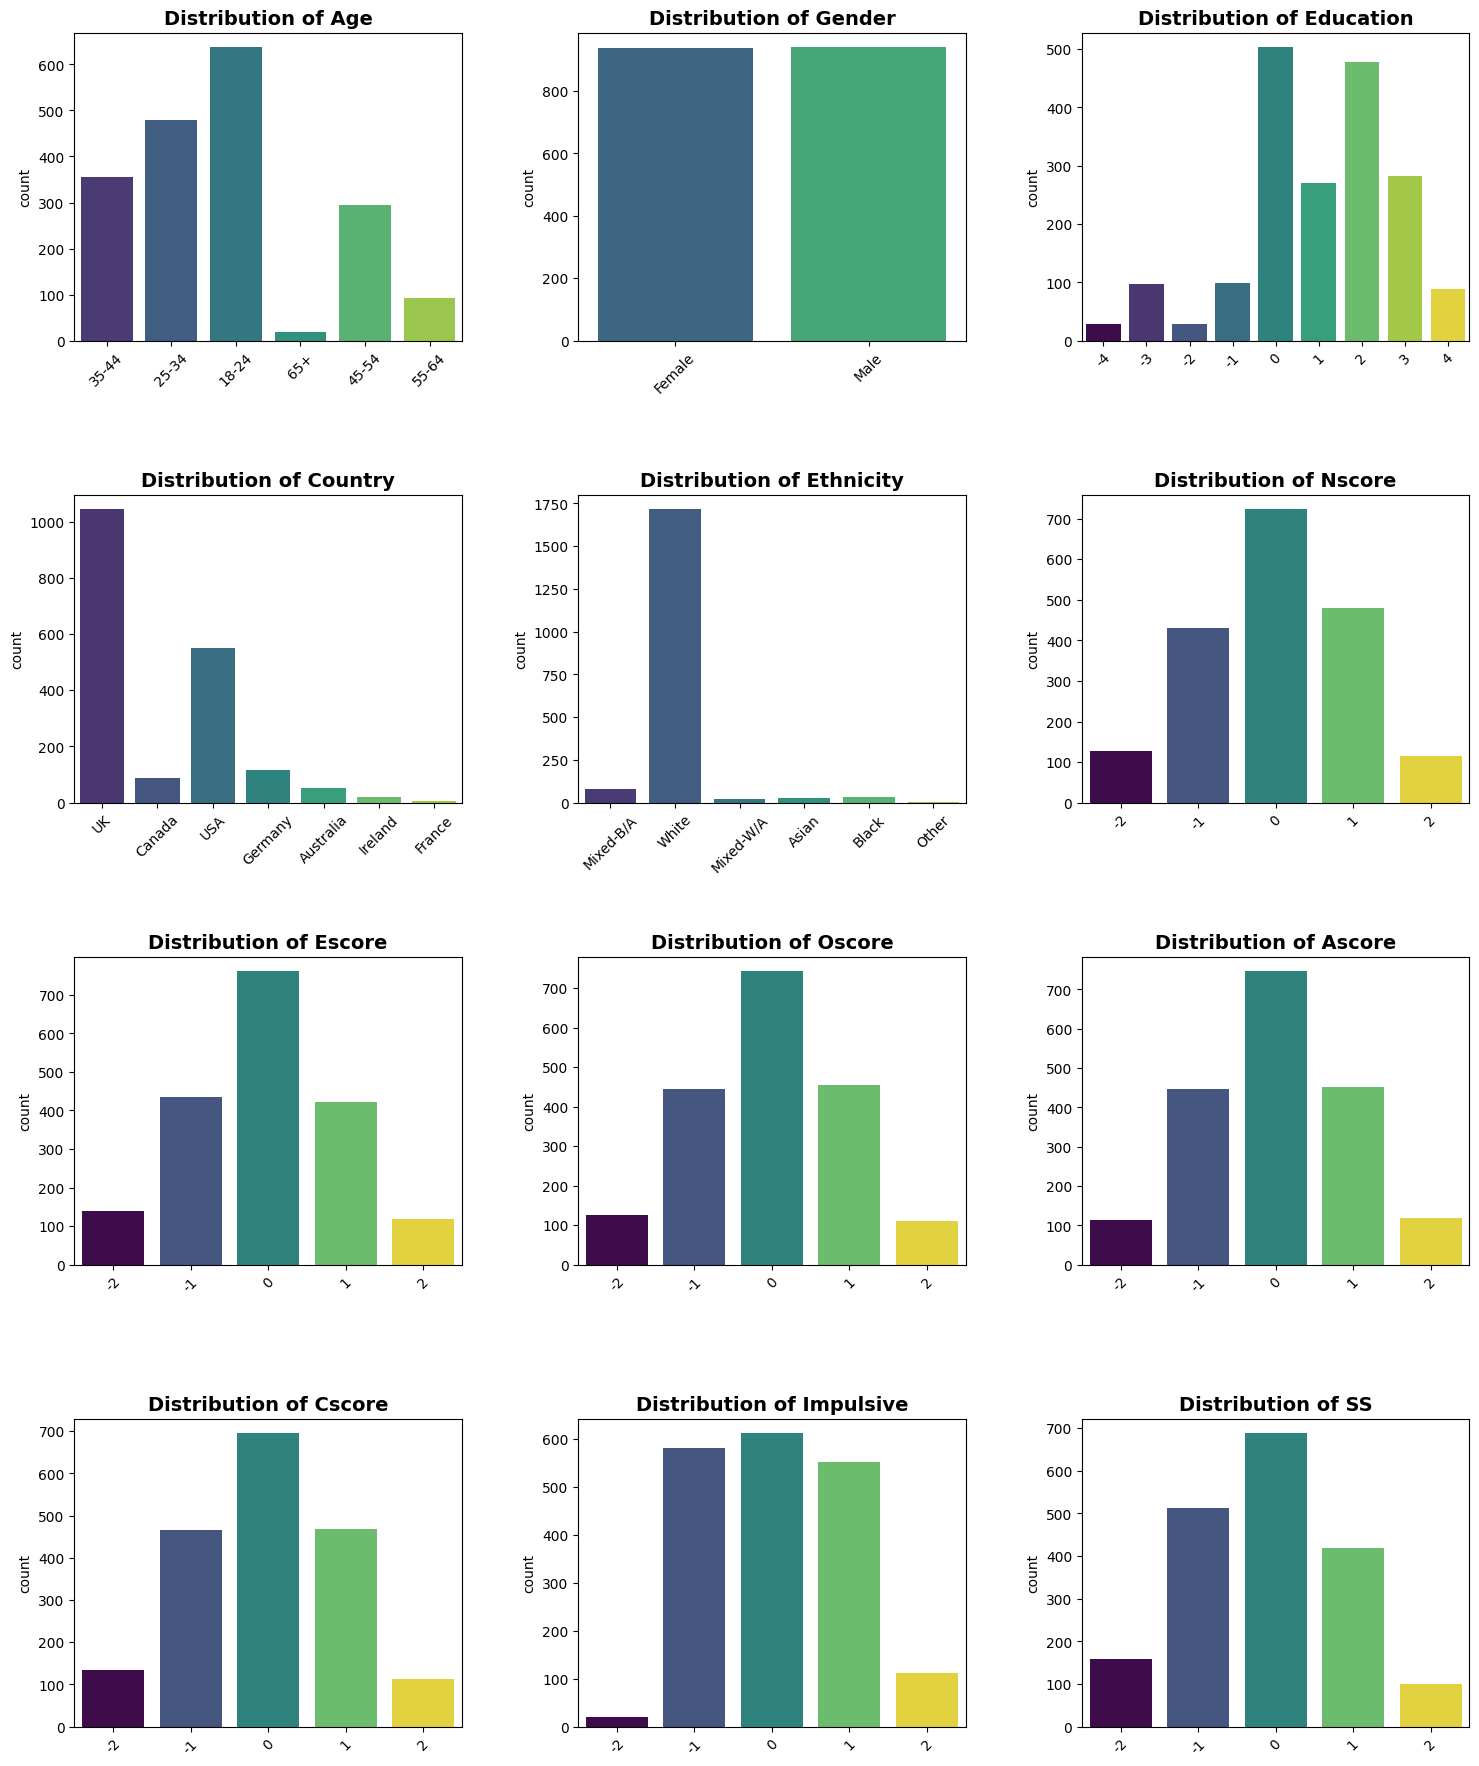

<Figure size 640x480 with 0 Axes>

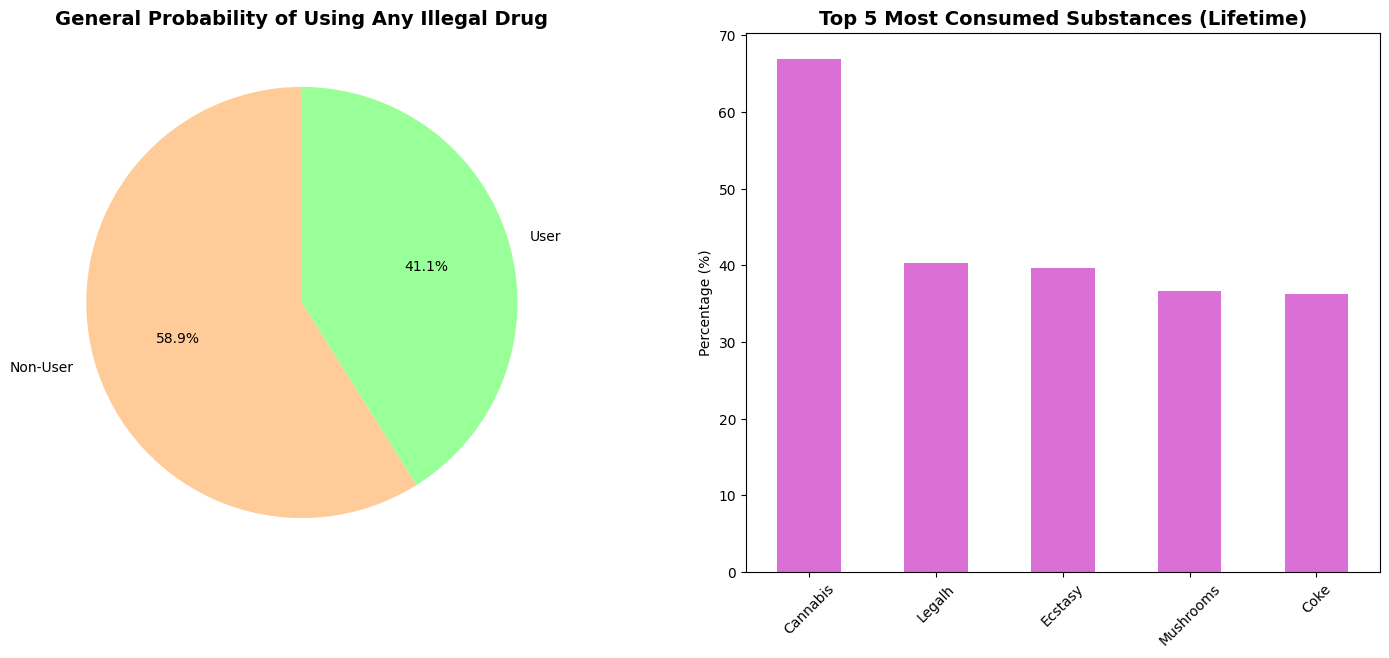

<Figure size 640x480 with 0 Axes>

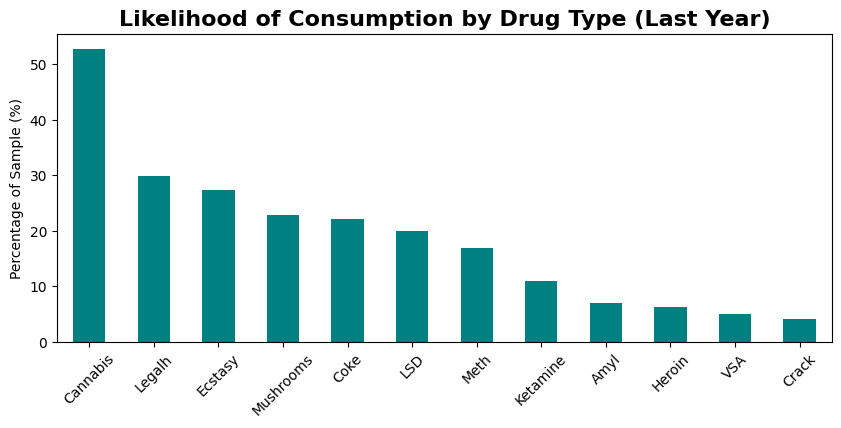

<Figure size 640x480 with 0 Axes>

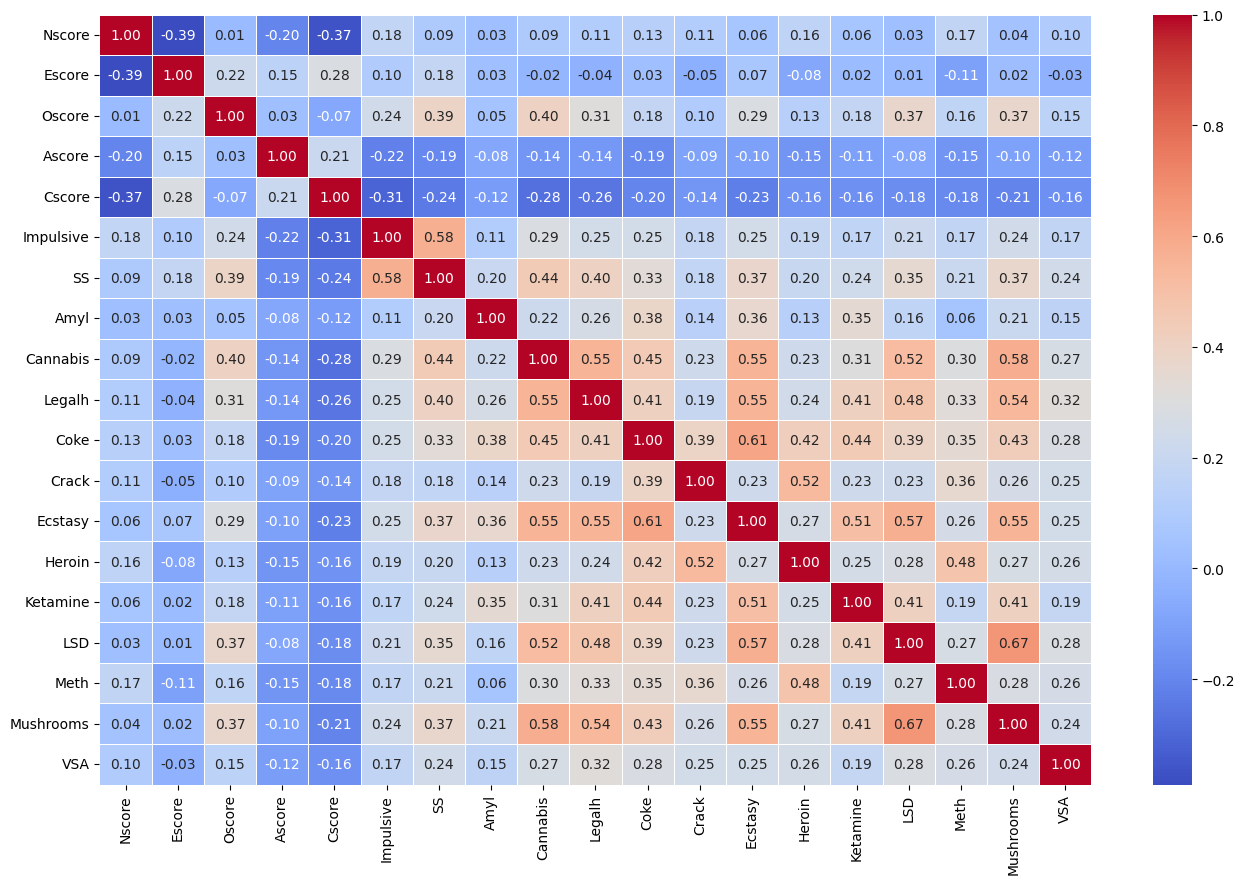

In [15]:
#שלב 4- ניתוח נתונים, ניקוי והכנה
# 1. הגדרת רשימת החומרים

illegal_substances = [
    'Amyl', 'Cannabis', 'Legalh',
    'Coke', 'Crack', 'Ecstasy', 'Heroin', 'Ketamine', 'LSD',
    'Meth', 'Mushrooms', 'VSA']

# --- הכנת רשימות העמודות ---
demographic_cols = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity']
personality_cols = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']
dist_cols = demographic_cols + personality_cols # 12 עמודות סה"כ

# ==========================================
# חלק 1: התפלגויות דמוגרפיות ואישיותיות (גריד של 4x3)
# ==========================================
fig1, axes1 = plt.subplots(nrows=4, ncols=3, figsize=(18, 22))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
axes1 = axes1.flatten()

for i, col in enumerate(dist_cols):
    sns.countplot(data=df, x=col, ax=axes1[i], palette="viridis", hue=col, legend=False)
    axes1[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes1[i].tick_params(axis='x', rotation=45)
    axes1[i].set_xlabel('')

plt.show()

plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ==========================================
# חלק 2: ניתוח שכיחות סמים (גרפים באותו גודל זה לצד זה)
# ==========================================
# הכנת הנתונים לצריכה כללית
df['Any_Illegal_User'] = df[illegal_substances].apply(lambda x: 1 if x.max() >= 0 else 0, axis=1)
usage_rates_ever = (df[illegal_substances] > -2).mean().sort_values(ascending=False) * 100

fig2, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(18, 7))

# 1. גרף עוגה - צריכה כללית
df['Any_Illegal_User'].value_counts().plot.pie(
    ax=ax_pie, autopct='%1.1f%%', labels=['Non-User', 'User'],
    colors=['#ffcc99','#99ff99'], startangle=90
)
ax_pie.set_title('General Probability of Using Any Illegal Drug', fontsize=14, fontweight='bold')
ax_pie.set_ylabel('')

# 2. גרף עמודות - 5 המובילים (Ever Used)
usage_rates_ever.head(5).plot(kind='bar', ax=ax_bar, color='orchid')
ax_bar.set_title('Top 5 Most Consumed Substances (Lifetime)', fontsize=14, fontweight='bold')
ax_bar.set_ylabel('Percentage (%)')
ax_bar.tick_params(axis='x', rotation=45)

plt.show()

plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ==========================================
# חלק 3: הסתברות לפי סוג סם (בשנה האחרונה)
# ==========================================
plt.figure(figsize=(10, 4))
drug_probs = (df[illegal_substances] >= 0).mean().sort_values(ascending=False) * 100
drug_probs.plot(kind='bar', color='teal')
plt.title('Likelihood of Consumption by Drug Type (Last Year)', fontsize=16, fontweight='bold')
plt.ylabel('Percentage of Sample (%)')
plt.xticks(rotation=45)
plt.show()

plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ==========================================
# חלק 4: מפת חום (Heatmap) - גדולה ובנפרד
# ==========================================
plt.figure(figsize=(16, 10))
numeric_cols = personality_cols + illegal_substances
corr_matrix = df[numeric_cols].corr()

# מציגים רק את הקשר בין אישיות לסמים
sns.heatmap(corr_matrix ,
            annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)


plt.show()

In [16]:
#  שלב 5: הכנת הנתונים למודלים
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from IPython.display import display

# 1. One-Hot Encoding לקטגוריות (Age, Gender, Country, Ethnicity)
categorical_cols = ['Age', 'Gender', 'Country', 'Ethnicity']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("✔ One-Hot Encoding בוצע")
print("מספר עמודות לאחר קידוד:", df_encoded.shape[1])
display(df_encoded.head(10))


# 2. בחירת הפיצ'רים הרלוונטיים (דמוגרפיה + אישיות)
personality_traits = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']

relevant_features = [
    col for col in df_encoded.columns
    if col in personality_traits or
       any(col.startswith(pre) for pre in ['Age_', 'Gender_', 'Country_', 'Ethnicity_', 'Education'])
]

X = df_encoded[relevant_features]
y = df_encoded['Cannabis_Binary']

print("\n✔ בחירת פיצ'רים הושלמה")
print("מספר פיצ'רים סופי:", len(relevant_features))
display(X.head(10))


# 3. נרמול (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n✔ נרמול הושלם — X_scaled מוכן")
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
display(X_scaled_df.head(10))


# 4. פיצול ל-Train/Test (פיצול אחד לכל המודלים)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("\n✔ פיצול בוצע בהצלחה")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

✔ One-Hot Encoding בוצע
מספר עמודות לאחר קידוד: 64


,ID,Education,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS,Alcohol,...,Country_France,Country_Germany,Country_Ireland,Country_UK,Country_USA,Ethnicity_Black,Ethnicity_Mixed-B/A,Ethnicity_Mixed-W/A,Ethnicity_Other,Ethnicity_White
0,1,1,0,-1,-1,-1,0,0,-1,2,...,False,False,False,True,False,False,True,False,False,False
1,2,4,-1,2,1,1,0,-1,0,2,...,False,False,False,True,False,False,False,False,False,True
2,3,1,0,1,-1,-2,-1,-1,0,3,...,False,False,False,True,False,False,False,False,False,True
3,4,3,0,-1,0,1,1,-1,-1,1,...,False,False,False,True,False,False,False,False,False,True
4,5,4,1,-2,0,0,1,0,0,1,...,False,False,False,True,False,False,False,False,False,True
5,6,-1,-1,0,-2,2,2,-1,-2,-1,...,False,False,False,False,False,False,False,False,False,True
6,7,3,0,-1,0,0,1,0,0,3,...,False,False,False,False,True,False,False,False,False,True
7,8,-3,-1,2,-1,0,2,0,-1,2,...,False,False,False,True,False,False,False,False,False,True
8,9,1,1,2,-1,1,1,-1,-2,1,...,False,False,False,False,False,False,False,False,False,True
9,10,3,0,0,-1,1,0,-1,-1,3,...,False,False,False,True,False,False,False,False,False,True



✔ בחירת פיצ'רים הושלמה
מספר פיצ'רים סופי: 25


,Education,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS,Age_25-34,Age_35-44,...,Country_France,Country_Germany,Country_Ireland,Country_UK,Country_USA,Ethnicity_Black,Ethnicity_Mixed-B/A,Ethnicity_Mixed-W/A,Ethnicity_Other,Ethnicity_White
0,1,0,-1,-1,-1,0,0,-1,False,True,...,False,False,False,True,False,False,True,False,False,False
1,4,-1,2,1,1,0,-1,0,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1,0,1,-1,-2,-1,-1,0,False,True,...,False,False,False,True,False,False,False,False,False,True
3,3,0,-1,0,1,1,-1,-1,False,False,...,False,False,False,True,False,False,False,False,False,True
4,4,1,-2,0,0,1,0,0,False,True,...,False,False,False,True,False,False,False,False,False,True
5,-1,-1,0,-2,2,2,-1,-2,False,False,...,False,False,False,False,False,False,False,False,False,True
6,3,0,-1,0,0,1,0,0,False,False,...,False,False,False,False,True,False,False,False,False,True
7,-3,-1,2,-1,0,2,0,-1,False,True,...,False,False,False,True,False,False,False,False,False,True
8,1,1,2,-1,1,1,-1,-2,False,True,...,False,False,False,False,False,False,False,False,False,True
9,3,0,0,-1,1,0,-1,-1,False,False,...,False,False,False,True,False,False,False,False,False,True



✔ נרמול הושלם — X_scaled מוכן


,Education,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS,Age_25-34,Age_35-44,...,Country_France,Country_Germany,Country_Ireland,Country_UK,Country_USA,Ethnicity_Black,Ethnicity_Mixed-B/A,Ethnicity_Mixed-W/A,Ethnicity_Other,Ethnicity_White
0,0.002719,-0.013842,-0.967250,-0.997694,-1.020637,0.021042,-0.087631,-0.874165,-0.586168,2.070585,...,-0.051681,-0.259005,-0.103779,0.893248,-0.644620,-0.133775,4.678701,-0.101124,-0.040011,-3.253678
1,1.703646,-1.013140,2.023737,1.021359,1.006596,0.021042,-1.155704,0.109533,1.705994,-0.482955,...,-0.051681,-0.259005,-0.103779,0.893248,-0.644620,-0.133775,-0.213735,-0.101124,-0.040011,0.307344
2,0.002719,-0.013842,1.026741,-0.997694,-2.034253,-0.966373,-1.155704,0.109533,-0.586168,2.070585,...,-0.051681,-0.259005,-0.103779,0.893248,-0.644620,-0.133775,-0.213735,-0.101124,-0.040011,0.307344
3,1.136670,-0.013842,-0.967250,0.011832,1.006596,1.008458,-1.155704,-0.874165,-0.586168,-0.482955,...,-0.051681,-0.259005,-0.103779,0.893248,-0.644620,-0.133775,-0.213735,-0.101124,-0.040011,0.307344
4,1.703646,0.985455,-1.964246,0.011832,-0.007020,1.008458,-0.087631,0.109533,-0.586168,2.070585,...,-0.051681,-0.259005,-0.103779,0.893248,-0.644620,-0.133775,-0.213735,-0.101124,-0.040011,0.307344
5,-1.131233,-1.013140,0.029745,-2.007221,2.020212,1.995874,-1.155704,-1.857863,-0.586168,-0.482955,...,-0.051681,-0.259005,-0.103779,-1.119509,-0.644620,-0.133775,-0.213735,-0.101124,-0.040011,0.307344
6,1.136670,-0.013842,-0.967250,0.011832,-0.007020,1.008458,-0.087631,0.109533,-0.586168,-0.482955,...,-0.051681,-0.259005,-0.103779,-1.119509,1.551301,-0.133775,-0.213735,-0.101124,-0.040011,0.307344
7,-2.265185,-1.013140,2.023737,-0.997694,-0.007020,1.995874,-0.087631,-0.874165,-0.586168,2.070585,...,-0.051681,-0.259005,-0.103779,0.893248,-0.644620,-0.133775,-0.213735,-0.101124,-0.040011,0.307344
8,0.002719,0.985455,2.023737,-0.997694,1.006596,1.008458,-1.155704,-1.857863,-0.586168,2.070585,...,-0.051681,-0.259005,-0.103779,-1.119509,-0.644620,-0.133775,-0.213735,-0.101124,-0.040011,0.307344
9,1.136670,-0.013842,0.029745,-0.997694,1.006596,0.021042,-1.155704,-0.874165,-0.586168,-0.482955,...,-0.051681,-0.259005,-0.103779,0.893248,-0.644620,-0.133775,-0.213735,-0.101124,-0.040011,0.307344



✔ פיצול בוצע בהצלחה
X_train: (1501, 25)
X_test: (376, 25)
y_train: (1501,)
y_test: (376,)


Accuracy: 0.8164893617021277

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.39      0.51        92
           1       0.83      0.95      0.89       284

    accuracy                           0.82       376
   macro avg       0.78      0.67      0.70       376
weighted avg       0.81      0.82      0.79       376



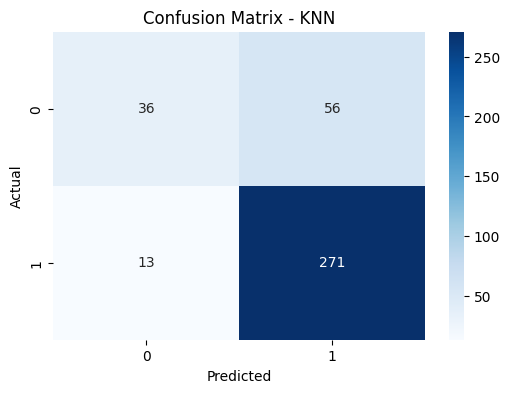

In [17]:
#מודל 1-KNN
#מודל KNN מנבא האם אדם משתמש בקנאביס באמצעות מציאת הקי  נבדקים הדומים לו ביותר בנתונים (למשל לפי גיל, תכונות אישיות ושימושים אחרים), וסיווגו לפי הרוב בקבוצת השכנים הקרובים
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. יצירת המודל KNN
knn = KNeighborsClassifier(n_neighbors=20) #בחרנו K=20 לאחר בדיקות רבות ומצאנו שזה הקיי האופטימלי

# --- 2. אימון ---
knn.fit(X_train, y_train)

# --- 3. ניבוי ---
y_pred = knn.predict(X_test)

# --- 4. דיוק ---
print("Accuracy:", accuracy_score(y_test, y_pred))

# --- 5. דוח סיווג ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 6. מטריצת בלבול ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

--- Decision Tree Evaluation ---
Accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.95      0.74        92
           1       0.98      0.80      0.88       284

    accuracy                           0.84       376
   macro avg       0.79      0.87      0.81       376
weighted avg       0.89      0.84      0.84       376



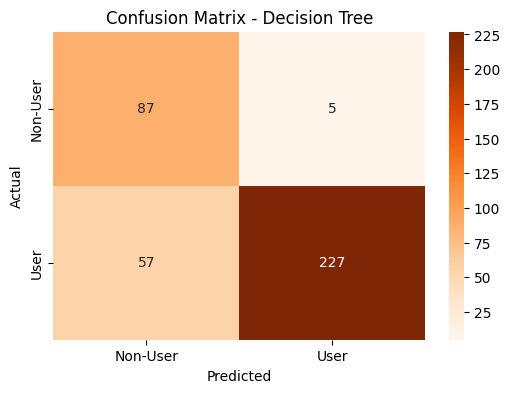

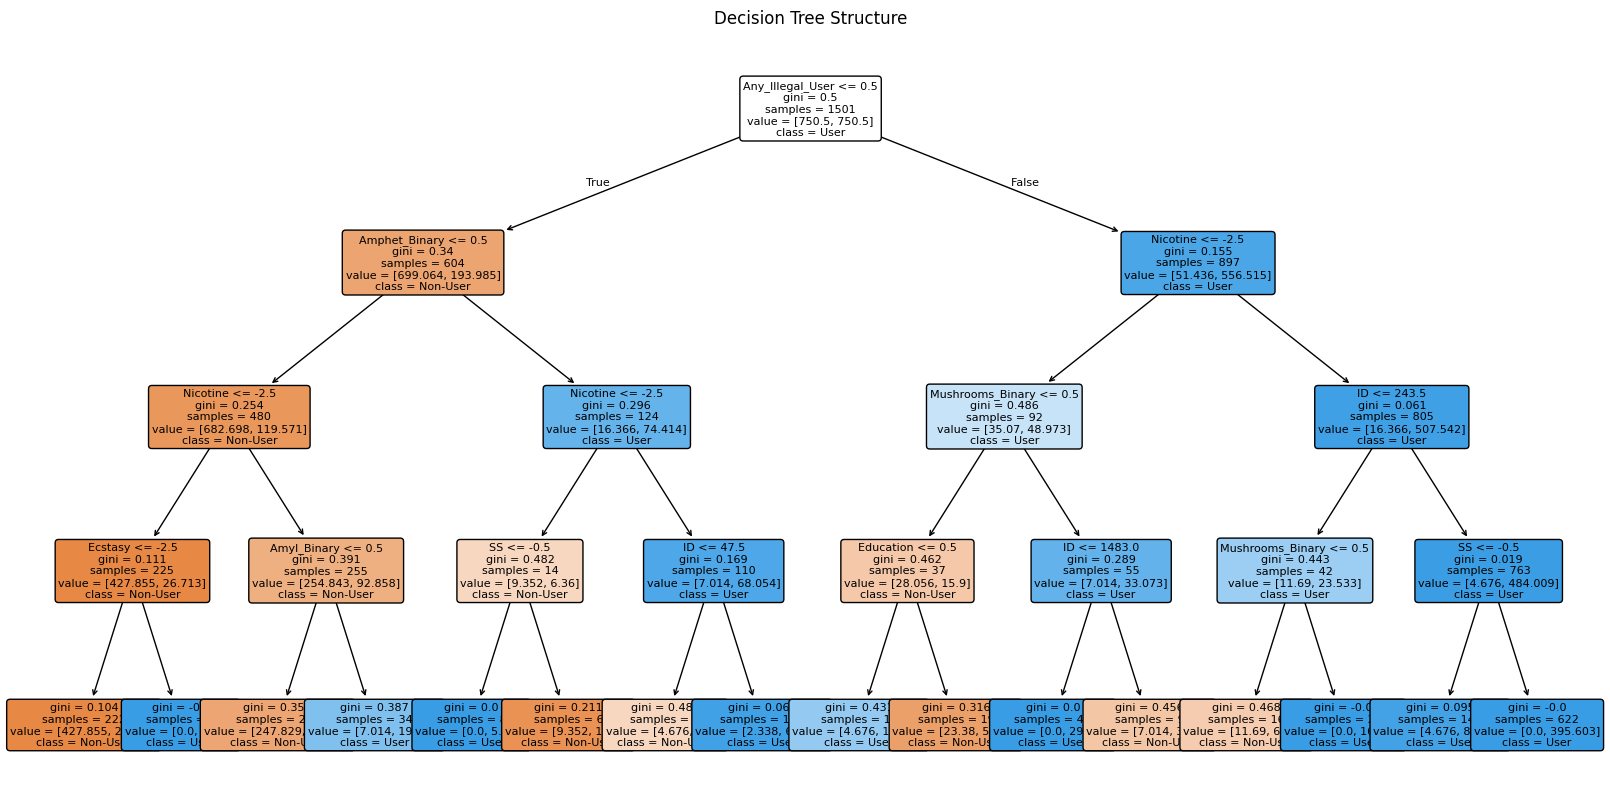

In [18]:
# מודל 2- עץ החלטה (Decision Tree Classifier)
# מודל זה בודק האם ניתן לנבא שימוש בקנאביס על בסיס מאפיינים אישיים ודמוגרפיים
# באמצעות עץ החלטה. עץ החלטה מאפשר להבין בצורה ויזואלית את תהליך קבלת ההחלטות.

from sklearn.tree import DecisionTreeClassifier, plot_tree
# 1. הכנת הנתונים
# X = כל המשתנים המסבירים (פיצ'רים)
# y = המשתנה המנובא (שימוש בקנאביס)
# חשוב להסיר את Cannabis ו-Cannabis_Binary מתוך X כדי למנוע זליגת מידע (Data Leakage)
X = df_encoded.drop(['Cannabis_Binary', 'Cannabis'], axis=1)
y = df_encoded['Cannabis_Binary']

# פיצול הנתונים לסט אימון (80%) וסט בדיקה (20%)
# random_state=42 מבטיח שנקבל את אותן תוצאות בכל הרצה
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. בניית המודל
# max_depth=4 מגביל את עומק העץ כדי למנוע Overfitting
# class_weight='balanced' מתקן את חוסר האיזון בין משתמשים ללא-משתמשים
dt_model = DecisionTreeClassifier(
    max_depth=4,
    class_weight='balanced',
    random_state=42
)

# 3. אימון המודל
dt_model.fit(X_train, y_train)

# 4. ניבוי על סט הבדיקה
y_pred_dt = dt_model.predict(X_test)

# 5. הערכת ביצועים
print("--- Decision Tree Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.2f}")

# דוח סיווג מציג Precision, Recall ו-F1 — חשוב במיוחד בדאטה לא מאוזן
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# 6. מטריצת בלבול
# מטריצה זו מראה כמה המודל צדק וכמה טעה עבור כל קטגוריה
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-User', 'User'],
            yticklabels=['Non-User', 'User'])
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 7. גרף עץ החלטה
# גרף זה מציג בצורה ויזואלית את כל הפיצולים שהמודל מבצע
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,     # שמות הפיצ'רים
    class_names=['Non-User', 'User'],  # שמות הקטגוריות
    filled=True,                 # צביעה לפי החלטות
    rounded=True,                # קצוות מעוגלים
    fontsize=8
)
plt.title("Decision Tree Structure")
plt.show()

--- Logistic Regression Evaluation ---
Accuracy: 0.76

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.83      0.62        92
           1       0.93      0.73      0.82       284

    accuracy                           0.76       376
   macro avg       0.71      0.78      0.72       376
weighted avg       0.82      0.76      0.77       376



<Figure size 640x480 with 0 Axes>

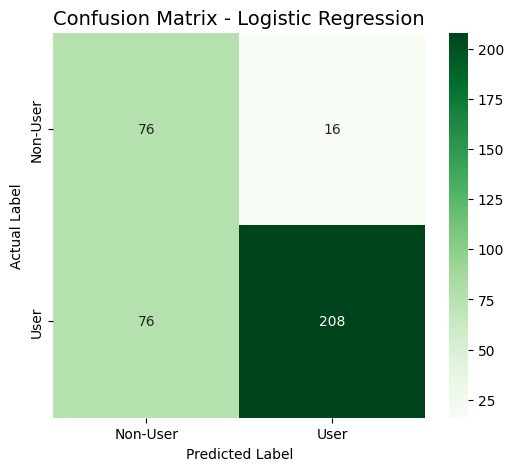

<Figure size 640x480 with 0 Axes>

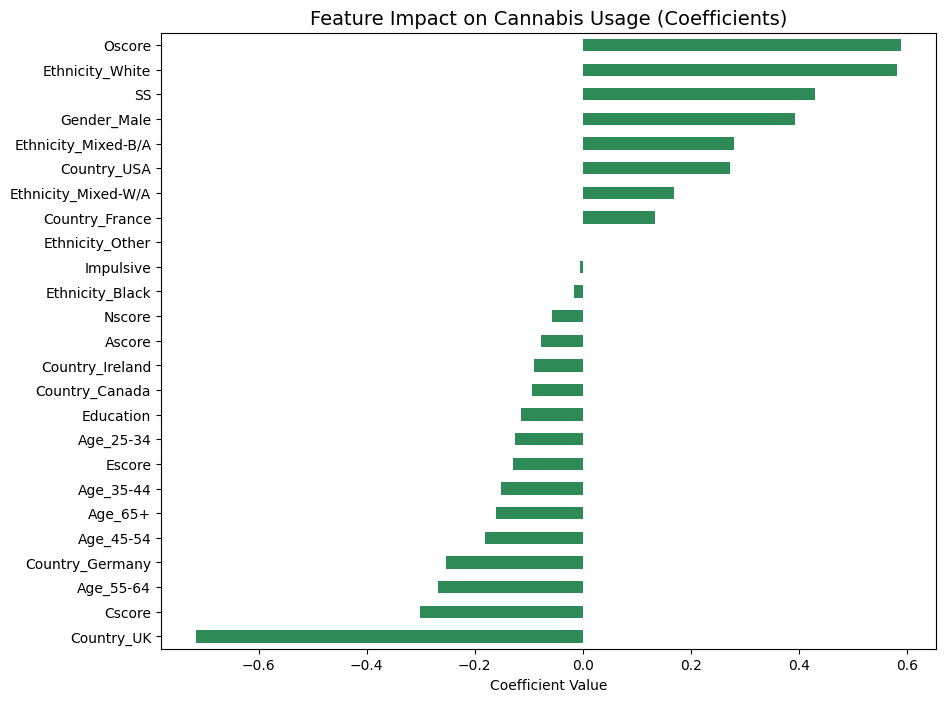

הסף האופטימלי שנמצא: 0.40


<Figure size 640x480 with 0 Axes>

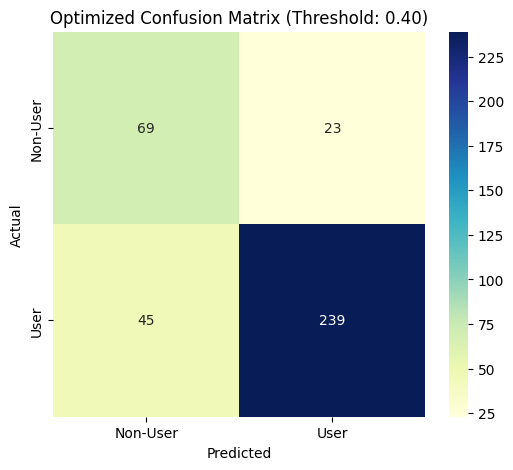


--- Optimized Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.61      0.75      0.67        92
           1       0.91      0.84      0.88       284

    accuracy                           0.82       376
   macro avg       0.76      0.80      0.77       376
weighted avg       0.84      0.82      0.83       376



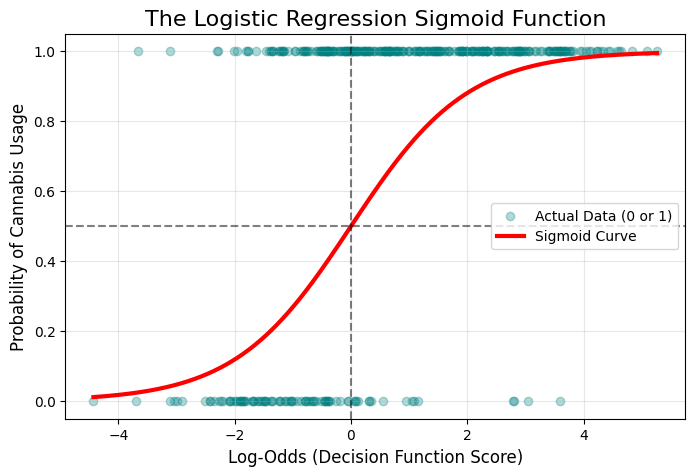

In [19]:
# מודל 3 - רגרסיה לוגיסטית (Logistic Regression)
from sklearn.linear_model import LogisticRegression

# 1. בחירת הפיצ'רים הרלוונטיים (אישיות ודמוגרפיה בלבד)
# אנחנו מוודאים שהמודל חוזה רק לפי מה שהגדרת בשאלת המחקר
personality_traits = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']
demographic_prefixes = ['Age_', 'Gender_', 'Country_', 'Ethnicity_', 'Education']

relevant_cols = [col for col in df_encoded.columns if col in personality_traits or
                 any(col.startswith(pre) for pre in demographic_prefixes)]

X_log = df_encoded[relevant_cols]
y_log = df_encoded['Cannabis_Binary']

# 2. פיצול ונרמול
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

scaler_l = StandardScaler()
X_train_scaled = scaler_l.fit_transform(X_train_l)
X_test_scaled = scaler_l.transform(X_test_l)

# 3. אימון המודל
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_l)

# 4. ביצועים ומדדי הערכה
y_pred_log = log_reg.predict(X_test_scaled)
print("--- Logistic Regression Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_l, y_pred_log):.2f}")
print("\nClassification Report:\n", classification_report(y_test_l, y_pred_log))

# ==========================================

plt.subplots_adjust(hspace=0.4, wspace=0.3)
# ==========================================
# 6. מטריצת בלבול (Confusion Matrix)
# ==========================================
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_l, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-User', 'User'],
            yticklabels=['Non-User', 'User'])
plt.title("Confusion Matrix - Logistic Regression", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ==========================================
# 7. חשיבות המשתנים (Coefficients)
# ==========================================
importance = pd.Series(log_reg.coef_[0], index=relevant_cols).sort_values()
plt.figure(figsize=(10, 8))
importance.plot(kind='barh', color='seagreen')
plt.title("Feature Impact on Cannabis Usage (Coefficients)", fontsize=14)
plt.xlabel("Coefficient Value")
plt.show()

plt.subplots_adjust(hspace=0.4, wspace=0.3)

from sklearn.linear_model import LogisticRegressionCV # גרסה שמחפשת פרמטרים לבד
from sklearn.metrics import roc_curve, precision_recall_curve

# 1. שימוש ב-LogisticRegressionCV - מודל שבודק בעצמו כמה רמות של "קושי" (Regularization)
# זה עוזר למנוע מצב של Overfitting או Underfitting
log_reg_optimized = LogisticRegressionCV(Cs=10, cv=5, class_weight='balanced', max_iter=2000, random_state=42)
#איזון הנתונים בגלל שקבוצת המשתמשים לא שווה לקבוצת הלא משתמשים
log_reg_optimized.fit(X_train_scaled, y_train_l)

# 2. מציאת ה"סף האופטימלי" (במקום סתם 0.5)
# אנחנו מוציאים את ההסתברויות שהמודל נתן
y_probs = log_reg_optimized.predict_proba(X_test_scaled)[:, 1]

# חישוב ה-ROC Curve כדי למצוא את הנקודה הטובה ביותר
fpr, tpr, thresholds = roc_curve(y_test_l, y_probs)
optimal_idx = np.argmax(tpr - fpr) # מדד Youden's J - מוצא את האיזון המקסימלי
optimal_threshold = thresholds[optimal_idx]

print(f"הסף האופטימלי שנמצא: {optimal_threshold:.2f}")

# 3. ניבוי לפי הסף החדש
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)


#ראיתי שמטריצת הבלבול קצת לא מדויקת ולכן ניסיתי לשפר אותה בעזרת שינוי הטראשהולד מה שהביא לדיוק גדול יותר
#
# 4. הצגת מטריצת בלבול משופרת
plt.figure(figsize=(6, 5))
cm_opt = confusion_matrix(y_test_l, y_pred_optimal) #
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Non-User', 'User'],
            yticklabels=['Non-User', 'User'])
plt.title(f"Optimized Confusion Matrix (Threshold: {optimal_threshold:.2f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 5. דוח סיווג מעודכן
print("\n--- Optimized Logistic Regression Report ---")
print(classification_report(y_test_l, y_pred_optimal))


z = log_reg.decision_function(X_test_scaled) # הערכים לפני המעבר בסיגמואיד
probs = log_reg.predict_proba(X_test_scaled)[:, 1] # ההסתברות הסופית (0 עד 1)

plt.figure(figsize=(8, 5))


# 5. ויזואליזציה של פונקציית הסיגמואיד (Sigmoid Curve)
# ==========================================
# כאן אנחנו לוקחים את ה"ציון" שהמודל נתן (Log-Odds) ומראים איך הסיגמואיד הופך אותו להסתברות
# ציור הנקודות של המודל
# שינוי קטן כדי לראות את הערכים האמיתיים (0 ו-1) מול עקומת הסיגמואיד
plt.scatter(z, y_test_l, alpha=0.3, color='teal', label='Actual Data (0 or 1)')

# ציור עקומת הסיגמואיד האידיאלית
z_range = np.linspace(z.min(), z.max(), 1000)
sigmoid_range = 1 / (1 + np.exp(-z_range))
plt.plot(z_range, sigmoid_range, color='red', linewidth=3, label='Sigmoid Curve')

plt.axhline(0.5, color='black', linestyle='--', alpha=0.5) # קו ההחלטה (50%)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.title("The Logistic Regression Sigmoid Function", fontsize=16)
plt.xlabel("Log-Odds (Decision Function Score)", fontsize=12)
plt.ylabel("Probability of Cannabis Usage", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


==================== RESULTS TABLE ====================
     Drug  Accuracy  F1-Score
     Amyl      0.71      0.38
 Cannabis      0.78      0.86
   Legalh      0.77      0.70
     Coke      0.64      0.58
    Crack      0.88      0.20
  Ecstasy      0.72      0.68
   Heroin      0.86      0.16
 Ketamine      0.79      0.17
      LSD      0.75      0.69
     Meth      0.80      0.48
Mushrooms      0.70      0.67
      VSA      0.76      0.21


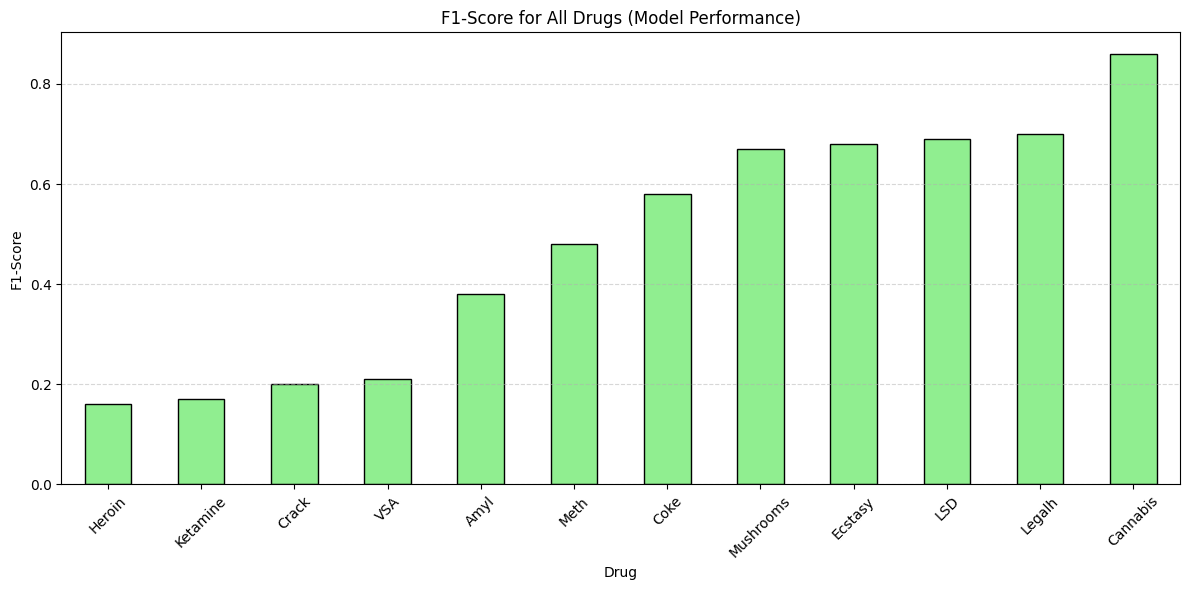

In [24]:
#Random Forest-מודל 4 מהספרות=ניבוי סוג שימוש בסם בהתאם לנותנים האישיים
#הוא יוצר "יער" של מאות עצי החלטה שונים. כל עץ מקבל רק חלק מהנתונים וחלק מהעמודות באופן אקראי.
#כל עץ נותן תחזית משלו. בסוף, המודל עושה "הצבעה". אם רוב העצים אומרים "משתמש", זו תהיה התחזית הסופית

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# `illegal_substances` is defined in cell S3PVl6Y2_dV4.
# We should use this list to iterate through drugs for the Random Forest model.
# Assuming `illegal_substances` is available from previous execution.

# שמירת תוצאות
results = []

for drug in illegal_substances: # Use the `illegal_substances` list for iterating
    target_col_name = drug + '_Binary'
    y = df_encoded[target_col_name] # Use df_encoded for targets
    X = X_scaled_df # Use X_scaled_df for features (demographic and personality)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Add class_weight for imbalanced classes
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # שמירה לטבלה
    results.append([drug, round(acc, 2), round(f1, 2)])

# יצירת טבלה
results_df = pd.DataFrame(results, columns=["Drug", "Accuracy", "F1-Score"])

print("\n==================== RESULTS TABLE ====================")
print(results_df.to_string(index=False))


plt.figure(figsize=(12, 6))
results_df.set_index("Drug")["F1-Score"].sort_values().plot(
    kind='bar', color='lightgreen', edgecolor='black'
)

plt.title("F1-Score for All Drugs (Model Performance)")
plt.ylabel("F1-Score")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#שאלת מחקר משנית בהתאם לתוצאות ה-Random Forest
#איך משפיעים הנתונים האישיים והדמוגרפיים על סוג הסם שבו משתמשים?


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


--- השוואת מודלים סופית: חיזוי שימוש בקנאביס ---


,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.351,0.254,1.000,0.405
1,Decision Tree,0.673,0.359,0.614,0.453
2,Logistic Regression,0.503,0.302,0.952,0.458
3,Random Forest,0.761,0.387,0.145,0.211


<Figure size 1200x700 with 0 Axes>

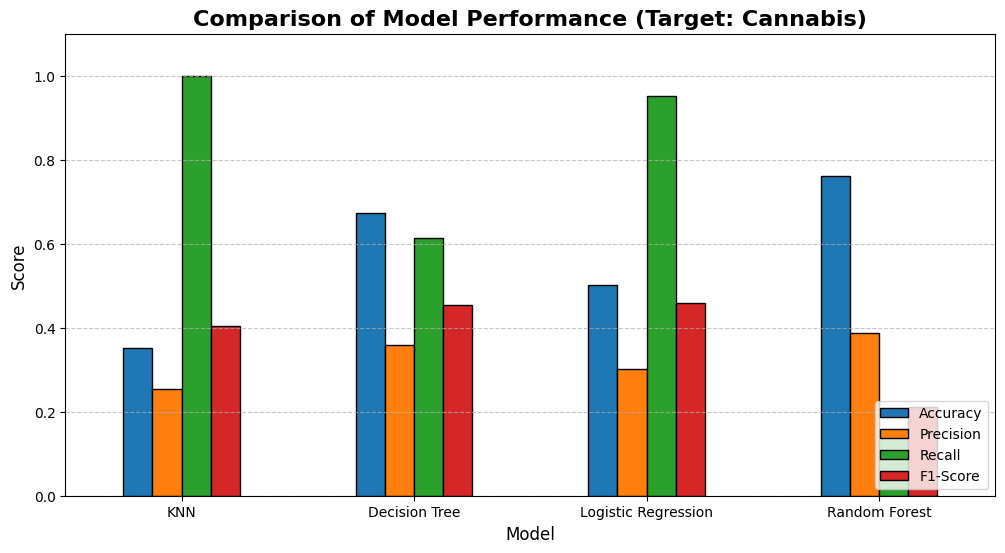

In [25]:
#השוואה בין המודלים
#איך משפיעים הנתונים האישיים והדמוגרפיים על סוג הסם שבו משתמשים?
# ==========================================
# ==========================================
# חלק 10 המעודכן: השוואה מסכמת בין המודלים (על קנאביס)
# ==========================================

from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# 1. הגדרת פונקציית עזר לאיסוף מדדים
def get_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }

# 2. הרצת ניבויים מחדש בצורה נקייה (כדי לוודא שכולם על אותם נתוני Test של קנאביס)
# וודאי שהשתמשת ב-X_test ו-y_test המקוריים משלב 5 (אלו של קנאביס עם הפיצ'רים המסוננים)

# ניבוי KNN (כבר אומן על X_train משלב 5)
y_pred_knn_final = knn.predict(X_test)

# ניבוי עץ החלטה - נאמן אותו רגע מחדש על הנתונים המסוננים כדי שיהיה הוגן
dt_model_final = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt_model_final.fit(X_train, y_train)
y_pred_dt_final = dt_model_final.predict(X_test)

# ניבוי רגרסיה לוגיסטית (השתמשי בגרסה האופטימלית שעשית עם ה-Threshold)
# הערה: לוגיסטית צריכה את הגרסה שעברה Scaling ספציפי אם עשית כזה
y_pred_log_final = (log_reg_optimized.predict_proba(X_test_scaled)[:, 1] >= optimal_threshold).astype(int)

# ניבוי יער אקראי - נאמן מודל אחד ספציפי לקנאביס לצורך ההשוואה
rf_cannabis = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_cannabis.fit(X_train, y_train)
y_pred_rf_final = rf_cannabis.predict(X_test)

# 3. איסוף כל התוצאות
final_comparison = []
final_comparison.append(get_metrics(y_test, y_pred_knn_final, 'KNN'))
final_comparison.append(get_metrics(y_test, y_pred_dt_final, 'Decision Tree'))
final_comparison.append(get_metrics(y_test, y_pred_log_final, 'Logistic Regression'))
final_comparison.append(get_metrics(y_test, y_pred_rf_final, 'Random Forest'))

# 4. יצירת הטבלה
comparison_df = pd.DataFrame(final_comparison)

print("--- השוואת מודלים סופית: חיזוי שימוש בקנאביס ---")
display(comparison_df.round(3))

# 5. ויזואליזציה של ההשוואה
plt.figure(figsize=(12, 7))
comparison_df.set_index('Model').plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title("Comparison of Model Performance (Target: Cannabis)", fontsize=16, fontweight='bold')
plt.ylabel("Score", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()